# `ac_video_jepa/main.py` — step by step

This notebook dissects the **training script** of the **action-conditioned** Video JEPA
(`examples/ac_video_jepa/main.py`), in the order the file executes.

What changed vs. the Video JEPA you already know (Moving MNIST):

- The world no longer moves on its own — an **agent** (a dot in a two-room maze) moves because of **actions**, so the predictor now takes `(state, action)` instead of just `state`.
- The conv predictor is replaced by a **GRU** (`RNNPredictor`) and unrolling switches from `parallel` to **`autoregressive`**.
- The regularizer grows two new terms: **temporal similarity** and an **Inverse Dynamics Model** (predict the action from two consecutive states).
- The probe is no longer a pixel decoder: it's an **`MLPXYHead`** that reads the agent's `(x, y)` out of the representation.

Steps ahead:

1. Config — `load_config` + `train.yaml`
2. Data — the two-rooms `WallDataset`
3. Encoder — `ImpalaEncoder`
4. Predictor — `RNNPredictor` (a GRU)
5. Regularizer — `VC_IDM_Sim_Regularizer`
6. Assembling the `JEPA`
7. `jepa.unroll` — the training forward pass
8. Prober — `MLPXYHead` + `JEPAProbe`
9. Optimizers, AMP, and one real training step
10. Eval hooks & checkpointing

In [1]:
import sys
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parents[1]          # examples/my_ac_video_jepa -> repo root
sys.path.insert(0, str(REPO_ROOT))

from eb_jepa.architectures import (
    ImpalaEncoder,
    InverseDynamicsModel,
    Projector,
    RNNPredictor,
)
from eb_jepa.datasets.utils import init_data
from eb_jepa.jepa import JEPA, JEPAProbe
from eb_jepa.losses import SquareLossSeq, VC_IDM_Sim_Regularizer
from eb_jepa.schedulers import CosineWithWarmup
from eb_jepa.state_decoder import MLPXYHead
from eb_jepa.training_utils import load_config, setup_seed

device = torch.device("cpu")   # main.py picks cuda if available; everything here runs on CPU
setup_seed(1)                  # cfg.meta.seed
print("device:", device)

[INFO    ][2026-07-08 09:20:54][eb_jepa.training_utils][setup_seed               ] Random seed set to 1
device: cpu


---
## 1. Config — `load_config` + `train.yaml`

`run()` starts by loading `cfgs/train.yaml` into an OmegaConf object; CLI overrides arrive as
dot-notation kwargs (`model.henc=64`). Then it builds an experiment folder and sets up wandb —
plumbing we skip here.

In [2]:
cfg = load_config(REPO_ROOT / "examples/ac_video_jepa/cfgs/train.yaml")

print("model:", dict(cfg.model))
print()
print("regularizer:", dict(cfg.model.regularizer))
print()
print("optim:", dict(cfg.optim))

[INFO    ][2026-07-08 09:21:42][eb_jepa.training_utils][load_config              ] Loaded config from /Users/hawardizayee/Desktop/AMI/eb_jepa/examples/ac_video_jepa/cfgs/train.yaml
model: {'compile': True, 'dobs': 2, 'henc': 32, 'hpre': 32, 'dstc': 32, 'nsteps': 8, 'encoder_architecture': 'impala', 'train_rollout': 'last', 'encoder_skip_connections': True, 'predictor_skip_connections': True, 'regularizer': {'cov_coeff': 8, 'std_coeff': 16, 'sim_coeff_t': 12, 'idm_coeff': 1, 'first_t_only': False, 'spatial_as_samples': False, 'use_proj': False, 'idm_after_proj': False, 'sim_t_after_proj': False}}

regularizer: {'cov_coeff': 8, 'std_coeff': 16, 'sim_coeff_t': 12, 'idm_coeff': 1, 'first_t_only': False, 'spatial_as_samples': False, 'use_proj': False, 'idm_after_proj': False, 'sim_t_after_proj': False}

optim: {'epochs': 12, 'lr': 0.001, 'grad_clip_enc': 2.0, 'grad_clip_pred': 2.0, 'weight_decay': 1e-05}


---
## 2. Data — the two-rooms `WallDataset`

`init_data("two_rooms", ...)` merges `eb_jepa/datasets/two_rooms/data_config.yaml` with the
overrides in `train.yaml`, then builds `WallDataset` loaders. There are **no files on disk** —
every `__getitem__` *simulates* a fresh trajectory: a dot random-walks through two rooms
separated by a wall with a door, and a 17-step window is cut out of the 91-step episode.

We shrink `size` / `batch_size` so the notebook stays light (real training: 100 000 samples,
batch 384).

In [3]:
loader, val_loader, data_config = init_data(
    env_name=cfg.data.env_name,                        # "two_rooms"
    cfg_data={"size": 64, "batch_size": 16, "num_workers": 0, "device": "cpu"},
)

x, a, loc, wall_x, door_y = next(iter(loader))         # main.py unpacks (x, a, loc, _, _)

print("x    (states)    :", x.shape)     # (16, 2, 17, 65, 65)  [B, C, T, H, W]
print("a    (actions)   :", a.shape)     # (16, 2, 17)          [B, A, T]
print("loc  (locations) :", loc.shape)   # (16, 2, 17)          [B, 2, T]
print("wall_x           :", wall_x.shape)
print("door_y           :", door_y.shape)

x    (states)    : torch.Size([16, 2, 17, 65, 65])
a    (actions)   : torch.Size([16, 2, 17])
loc  (locations) : torch.Size([16, 2, 17])
wall_x           : torch.Size([16, 1])
door_y           : torch.Size([16, 1])


The 2 channels (`cfg.model.dobs = 2`) are **dot** and **walls**. Pixels are normalized
(mean/std), so grays are shifted — the dot is still obvious.

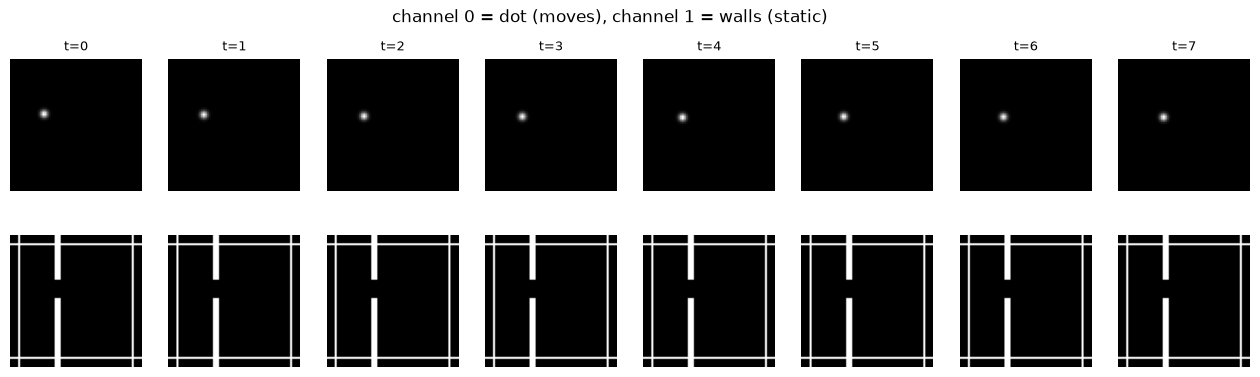

In [4]:
sample = 0
fig, axes = plt.subplots(2, 8, figsize=(16, 4.2))
for t in range(8):
    axes[0, t].imshow(x[sample, 0, t], cmap="gray")
    axes[0, t].set_title(f"t={t}", fontsize=9)
    axes[1, t].imshow(x[sample, 1, t], cmap="gray")
    axes[0, t].axis("off"); axes[1, t].axis("off")
axes[0, 0].set_ylabel("dot")
fig.suptitle("channel 0 = dot (moves), channel 1 = walls (static)")
plt.show()

**Actions are displacements.** `a[:, :, t]` is the (Δx, Δy) that moves the dot from frame `t`
to `t+1` — unnormalized pixels. Locations *are* normalized, so we undo that first. The two match
exactly except where the dot bumped into a wall (action commanded, dot didn't move).

In [5]:
normalizer = loader.dataset.normalizer
loc_px = normalizer.unnormalize_location(loc.permute(0, 2, 1))   # [B, T, 2] in pixels

deltas  = loc_px[:, 1:] - loc_px[:, :-1]                         # [B, T-1, 2]
actions = a.permute(0, 2, 1)[:, :-1]                             # [B, T-1, 2]

print("location deltas  [sample 0, t=0..3]:\n", deltas[0, :4])
print("actions          [sample 0, t=0..3]:\n", actions[0, :4])
print("\nmax |delta - action| over batch:", (deltas - actions).abs().max().item(),
      " <- nonzero only at wall bumps")

location deltas  [sample 0, t=0..3]:
 tensor([[0.7192, 0.4124],
        [0.8860, 0.6747],
        [0.0103, 0.2191],
        [0.9762, 0.4403]])
actions          [sample 0, t=0..3]:
 tensor([[0.7192, 0.4124],
        [0.8860, 0.6747],
        [0.0103, 0.2191],
        [0.9762, 0.4403]])

max |delta - action| over batch: 1.685934066772461  <- nonzero only at wall bumps


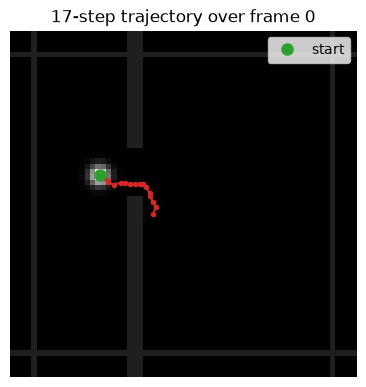

In [6]:
plt.figure(figsize=(4.5, 4.5))
plt.imshow(x[sample, 0, 0] + x[sample, 1, 0], cmap="gray")
plt.plot(loc_px[sample, :, 0], loc_px[sample, :, 1], "o-", color="tab:red", ms=3)
plt.plot(loc_px[sample, 0, 0], loc_px[sample, 0, 1], "o", color="tab:green", ms=8, label="start")
plt.legend(); plt.axis("off")
plt.title("17-step trajectory over frame 0")
plt.show()

---
## 3. Encoder — `ImpalaEncoder`

Video JEPA's encoder kept a **spatial map**; this one flattens everything into a single
**512-d vector per frame** (`[B, 512, T, 1, 1]`) — exactly the shape a GRU hidden state wants.

Three ResNet stacks (`stack_sizes = (16, henc, dstc) = (16, 32, 32)` from `train.yaml`), each
maxpooling ×2 (65 → 33 → 17 → 9), then flatten → `Linear(32·9·9, 512)` → `LayerNorm`.

`main.py` first pushes a **1-frame dummy input** through to discover the output shape — that's
where `f, h, w` come from (used later to size the IDM).

In [7]:
test_input = torch.rand(1, cfg.model.dobs, 1, data_config.img_size, data_config.img_size)

encoder = ImpalaEncoder(
    width=1,
    stack_sizes=(16, cfg.model.henc, cfg.model.dstc),   # (16, 32, 32)
    num_blocks=2,
    dropout_rate=None,
    layer_norm=False,
    input_channels=cfg.model.dobs,
    final_ln=True,
    mlp_output_dim=512,
    input_shape=(cfg.model.dobs, data_config.img_size, data_config.img_size),
)
test_output = encoder(test_input)
_, f, _, h, w = test_output.shape

print("test_output shape:", test_output.shape)   # (1, 512, 1, 1, 1)
print(f"f={f}, h={h}, w={w}  ->  state is a flat {f}-d vector per frame")

with torch.no_grad():
    s_x = encoder(x)
print("encoder(x) shape :", s_x.shape)           # (16, 512, 17, 1, 1)

test_output shape: torch.Size([1, 512, 1, 1, 1])
f=512, h=1, w=1  ->  state is a flat 512-d vector per frame


encoder(x) shape : torch.Size([16, 512, 17, 1, 1])


---
## 4. Predictor — `RNNPredictor` (a GRU with the roles swapped)

The usual GRU picture is "input sequence in, hidden state out". Here it's inverted:

- **hidden state** = the JEPA state `s_t` (512-d)
- **input** = the action `a_t` (2-d)
- **new hidden state** = the predicted next state `ŝ_{t+1}`

One `forward` = one step of world dynamics. Two details from `main.py`:

- `aencoder = nn.Identity()` — actions are already 2-d vectors, nothing to encode.
- The predictor **reuses the encoder's `final_ln` module**, so predictions live in the same
  LayerNorm-ed space as encoder outputs.
- `is_rnn = True`, `context_length = 0` — flags `jepa.unroll` reads later.

In [8]:
predictor = RNNPredictor(hidden_size=encoder.mlp_output_dim, final_ln=encoder.final_ln)
aencoder = nn.Identity()

state_t  = s_x[:, :, :1]        # (16, 512, 1, 1, 1) — one frame's state
action_t = a[:, :, :1]          # (16, 2, 1)         — one action

with torch.no_grad():
    next_state = predictor(state_t, action_t)

print("state_t    :", state_t.shape)     # (16, 512, 1, 1, 1)
print("action_t   :", action_t.shape)    # (16, 2, 1)
print("next_state :", next_state.shape)  # (16, 512, 1, 1, 1)
print("is_rnn:", predictor.is_rnn, "| context_length:", predictor.context_length)

state_t    : torch.Size([16, 512, 1, 1, 1])
action_t   : torch.Size([16, 2, 1])
next_state : torch.Size([16, 512, 1, 1, 1])
is_rnn: True | context_length: 0


---
## 5. Regularizer — `VC_IDM_Sim_Regularizer`

There is **no EMA target encoder** in this codebase — the same encoder produces both inputs and
prediction targets. What stops it from collapsing to a constant is this regularizer, a sum of
four terms (coefficients from `train.yaml`):

| Term | What it fights | Coeff |
|---|---|---|
| `std_loss` (hinge) | collapse — every feature must keep std ≥ 1 across the batch | 16 |
| `cov_loss` | redundancy — off-diagonal covariance pushed to 0 | 8 |
| `sim_loss_t` | jitter — consecutive frames should have *similar* embeddings | 12 |
| `idm_loss` | losing action info — an MLP must recover `a_t` from `(s_t, s_{t+1})` | 1 |

`std` and `sim_t` pull in opposite directions (spread out, but move smoothly); `idm` guarantees
the state keeps whatever the *agent* controls. The **IDM** is a small trainable MLP:
`state_dim = h·w·f = 512` (no projector — `use_proj: false`, so `projector = None`).

In [9]:
idm = InverseDynamicsModel(
    state_dim=h * w * f,     # 1*1*512 — projector is None since use_proj=false
    hidden_dim=256,
    action_dim=2,
).to(device)

regularizer = VC_IDM_Sim_Regularizer(
    cov_coeff=cfg.model.regularizer.cov_coeff,        # 8
    std_coeff=cfg.model.regularizer.std_coeff,        # 16
    sim_coeff_t=cfg.model.regularizer.sim_coeff_t,    # 12
    idm_coeff=cfg.model.regularizer.get("idm_coeff", 0.1),  # 1
    idm=idm,
    first_t_only=cfg.model.regularizer.get("first_t_only"),  # False -> all 17 frames used
    projector=None,                                    # use_proj: false
    spatial_as_samples=cfg.model.regularizer.spatial_as_samples,
    idm_after_proj=cfg.model.regularizer.idm_after_proj,
    sim_t_after_proj=cfg.model.regularizer.sim_t_after_proj,
)

with torch.no_grad():
    reg_w, reg_unw, reg_dict = regularizer(s_x, a)

print("weighted reg loss  :", f"{reg_w.item():.4f}")
print("unweighted reg loss:", f"{reg_unw.item():.4f}")
for k, v in reg_dict.items():
    print(f"  {k:<12}: {v:.4f}")

weighted reg loss  : 6.5694
unweighted reg loss: 0.9743
  cov_loss    : 0.0197
  std_loss    : 0.3510
  sim_loss_t  : 0.0174
  idm_loss    : 0.5861


---
## 6. Assembling the `JEPA`

Same container class as Video JEPA: `JEPA(encoder, aencoder, predictor, regularizer, ploss)`
with `ploss = SquareLossSeq()` (plain MSE between predicted and encoded states).

One subtlety: the regularizer *holds* the IDM, so `jepa.parameters()` includes the IDM's weights —
it is trained jointly by the same optimizer.

In [10]:
ploss = SquareLossSeq()
jepa = JEPA(encoder, aencoder, predictor, regularizer, ploss).to(device)

encoder_params   = sum(p.numel() for p in encoder.parameters())
predictor_params = sum(p.numel() for p in predictor.parameters())
idm_params       = sum(p.numel() for p in idm.parameters())
total_params     = sum(p.numel() for p in jepa.parameters())

print(f"encoder   : {encoder_params:,} params")
print(f"predictor : {predictor_params:,} params")
print(f"idm       : {idm_params:,} params")
print(f"jepa total: {total_params:,} params  (encoder + predictor + idm)")

encoder   : 1,426,096 params
predictor : 793,600 params
idm       : 328,706 params
jepa total: 2,547,378 params  (encoder + predictor + idm)


---
## 7. `jepa.unroll` — the training forward pass

The heart of the training loop is a single call:

```python
jepa.unroll(x, a, nsteps=8, unroll_mode="autoregressive", ctxt_window_time=1,
            compute_loss=True, return_all_steps=False)
```

Video JEPA used `parallel` mode (predict all frames at once, re-feed ground-truth context).
Here `autoregressive` mode steps through time, and — because `is_rnn=True` — the context window
is forced to 1: the GRU starts from the **encoded frame 0** and then eats its **own predictions**:

In [11]:
print(f"{'step i':>6} | {'GRU hidden in':>13} | {'GRU input':>9} | {'predicts':>8} | {'loss target':>11}")
print("-" * 62)
for i in range(cfg.model.nsteps):
    hidden = "s_0 (encoded)" if i == 0 else f"ŝ_{i}"
    print(f"{i:>6} | {hidden:>13} | {'a_'+str(i):>9} | {'ŝ_'+str(i+1):>8} | {'s_'+str(i+1):>11}")

step i | GRU hidden in | GRU input | predicts | loss target
--------------------------------------------------------------
     0 | s_0 (encoded) |       a_0 |      ŝ_1 |         s_1
     1 |           ŝ_1 |       a_1 |      ŝ_2 |         s_2
     2 |           ŝ_2 |       a_2 |      ŝ_3 |         s_3
     3 |           ŝ_3 |       a_3 |      ŝ_4 |         s_4
     4 |           ŝ_4 |       a_4 |      ŝ_5 |         s_5
     5 |           ŝ_5 |       a_5 |      ŝ_6 |         s_6
     6 |           ŝ_6 |       a_6 |      ŝ_7 |         s_7
     7 |           ŝ_7 |       a_7 |      ŝ_8 |         s_8


Each `ŝ_{i+1}` is compared to the encoder's `s_{i+1}` (MSE, averaged over the 8 steps).
Note the asymmetry: the **prediction loss** only touches frames 0–8, but the **regularizer**
already ran on all 17 encoded frames (it's computed once, at the top of `unroll`).

`unroll` returns `(predicted_states, losses)` where `losses` is a 5-tuple — exactly what
`main.py` unpacks as `(jepa_loss, regl, regl_unweight, regldict, pl)`.

In [12]:
preds, (jepa_loss, regl, regl_unweight, regldict, pl) = jepa.unroll(
    x,
    a,
    nsteps=cfg.model.nsteps,            # 8
    unroll_mode="autoregressive",
    ctxt_window_time=1,
    compute_loss=True,
    return_all_steps=False,
)

print("preds shape:", preds.shape)      # (16, 512, 9, 1, 1) — context frame + 8 predictions
print()
print(f"jepa_loss (reg + pred): {jepa_loss.item():.4f}")
print(f"  regl   (weighted)   : {regl.item():.4f}")
print(f"  pl     (prediction) : {pl.item():.4f}")
print("  regldict:", {k: round(v, 4) for k, v in regldict.items()})

preds shape: torch.Size([16, 512, 9, 1, 1])

jepa_loss (reg + pred): 7.4140
  regl   (weighted)   : 6.5694
  pl     (prediction) : 0.8446
  regldict: {'cov_loss': 0.0197, 'std_loss': 0.351, 'sim_loss_t': 0.0174, 'idm_loss': 0.5861}


---
## 8. Prober — `MLPXYHead` + `JEPAProbe`

To *measure* whether the representation contains the agent's position, `main.py` trains a probe:
a 2-layer MLP (`512 → 512 → 2`) reading `(x, y)` from the state. `JEPAProbe` **detaches the
encoder** — probe gradients never touch the JEPA (it has its own optimizer).

Two details:

- It's trained on the **first frame only**: `x[:, :, :1]` vs `loc[:, :, :1]`.
- The MSE is in *normalized* location units; `normalizer.unnormalize_mse` rescales it by
  `location_std² (≈ 16.1²)` so the logged number is in **pixels²**.

Weights are random here — shapes are real, the loss value is meaningless.

In [13]:
xy_head = MLPXYHead(
    input_shape=test_output.shape[1],       # 512
    normalizer=loader.dataset.normalizer,
).to(device)
xy_prober = JEPAProbe(jepa=jepa, head=xy_head, hcost=nn.MSELoss())

xy_loss = xy_prober(observations=x[:, :, :1], targets=loc[:, :, :1])

print("head input  :", tuple(x[:, :, :1].shape))     # (16, 2, 1, 65, 65)
print("head target :", tuple(loc[:, :, :1].shape))   # (16, 2, 1)
print(f"xy_loss (normalized units): {xy_loss.item():.4f}")
print(f"xy_loss (pixels^2)        : {loader.dataset.normalizer.unnormalize_mse(xy_loss).item():.2f}")

head input  : (16, 2, 1, 65, 65)
head target : (16, 2, 1)
xy_loss (normalized units): 0.9651
xy_loss (pixels^2)        : 250.74


---
## 9. Optimizers, AMP, and one real training step

Two independent optimizer stacks, both on a cosine schedule with 10 % warmup:

| | params | lr | extras |
|---|---|---|---|
| `jepa_optimizer` | encoder + predictor + IDM | 1e-3 | grad-clip 2.0 on encoder and predictor separately |
| `probe_optimizer` | `xy_head` only | 1e-3 | — |

On GPU, `main.py` wraps forward passes in `autocast(bfloat16)` and uses a `GradScaler`.
On CPU we disable AMP — with `enabled=False` every `scaler.*` call is a no-op passthrough,
so the code below is line-for-line the loop body of `main.py`.

In [14]:
steps_per_epoch = data_config.size // data_config.batch_size
total_steps = cfg.optim.epochs * steps_per_epoch

jepa_optimizer = torch.optim.AdamW(
    jepa.parameters(), lr=cfg.optim.lr, weight_decay=cfg.optim.get("weight_decay", 1e-6)
)
jepa_scheduler = CosineWithWarmup(jepa_optimizer, total_steps, warmup_ratio=0.1)

probe_optimizer = torch.optim.AdamW(xy_head.parameters(), lr=1e-3, weight_decay=1e-5)
probe_scheduler = CosineWithWarmup(probe_optimizer, total_steps, warmup_ratio=0.1)

from torch.amp import GradScaler, autocast
use_amp = False                                   # main.py: True, dtype=bfloat16 (GPU)
scaler = GradScaler(device.type, enabled=use_amp)

print("total_steps:", total_steps)

total_steps: 48


In [15]:
# --- one iteration of the training loop, same batch reused (overfit-one-batch sanity check)
for it in range(10):
    # JEPA step
    jepa_optimizer.zero_grad()
    with autocast(device.type, enabled=use_amp):
        _, (jepa_loss, regl, regl_unweight, regldict, pl) = jepa.unroll(
            x, a, nsteps=cfg.model.nsteps, unroll_mode="autoregressive",
            ctxt_window_time=1, compute_loss=True, return_all_steps=False,
        )
    scaler.scale(jepa_loss).backward()
    scaler.unscale_(jepa_optimizer)
    torch.nn.utils.clip_grad_norm_(jepa.encoder.parameters(), cfg.optim.grad_clip_enc)
    torch.nn.utils.clip_grad_norm_(jepa.predictor.parameters(), cfg.optim.grad_clip_pred)
    scaler.step(jepa_optimizer)
    scaler.update()
    jepa_scheduler.step()

    # probe step (separate optimizer, encoder detached inside JEPAProbe)
    probe_optimizer.zero_grad()
    with autocast(device.type, enabled=use_amp):
        xy_loss = xy_prober(observations=x[:, :, :1], targets=loc[:, :, :1])
        xy_loss = loader.dataset.normalizer.unnormalize_mse(xy_loss)
    scaler.scale(xy_loss).backward()
    scaler.step(probe_optimizer)
    scaler.update()
    probe_scheduler.step()

    if it % 3 == 0 or it == 9:
        print(f"it {it}: jepa_loss={jepa_loss.item():8.4f}  reg={regl.item():8.4f}  "
              f"pred={pl.item():.4f}  probe(px^2)={xy_loss.item():9.2f}")

it 0: jepa_loss=  7.4140  reg=  6.5694  pred=0.8446  probe(px^2)=   250.74


/Users/hawardizayee/Desktop/AMI/eb_jepa/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


it 3: jepa_loss=  4.2245  reg=  3.4305  pred=0.7940  probe(px^2)=    81.77


it 6: jepa_loss=  2.6622  reg=  2.2326  pred=0.4295  probe(px^2)=    74.76


it 9: jepa_loss=  2.1065  reg=  1.8413  pred=0.2652  probe(px^2)=    30.30


Both losses drop even on 10 iterations of a single batch. Note `total_loss` in `main.py`
is *only for the progress bar* — the two backward passes are fully independent
(`jepa_loss.backward()` and `xy_loss.backward()`).

---
## 10. Eval hooks & checkpointing

The rest of `main.py` is orchestration:

- **`enable_plan_eval`** builds a live `DotWall` environment (`env_creator`) and periodically runs
  two evaluations imported from `eval.py`:
  - `launch_unroll_eval` — encode a context frame, unroll the predictor with the *ground-truth*
    actions, decode predicted states with `xy_prober`, and compare against the real trajectory
    (every `light_eval_freq = 50` iters);
  - `launch_plan_eval` — full **planning**: use the world model + MPPI (`planning_mppi.yaml`)
    to pick actions that reach a goal, and report a success rate (every `eval_every_itr` iters).
- **`eval_only_mode`** skips training and just runs both of the above from a checkpoint.
- **`save_checkpoint`** writes `latest.pth.tar` every epoch (plus `e-{epoch}.pth.tar` snapshots):
  jepa weights, both optimizers, both schedulers, and the `xy_head` state.

Those two eval functions deserve their own deep dive (`eval.py`).

---
## Recap — Video JEPA → AC Video JEPA

| | Video JEPA (Moving MNIST) | AC Video JEPA (two-rooms) |
|---|---|---|
| **World** | digits move on their own | agent dot moves *because of actions* (`a_t ≈ Δlocation`) |
| **Encoder** | ResNet5, spatial map per frame | `ImpalaEncoder`, flat 512-d vector per frame |
| **Predictor** | conv net, no actions, `parallel` unroll | GRU: hidden = state, input = action, `autoregressive` unroll |
| **Anti-collapse** | VC (std + cov) | VC + temporal similarity + **IDM** |
| **Probe** | pixel decoder / detection head | `MLPXYHead` → agent's `(x, y)` |
| **Evaluation** | unroll quality | unroll quality **+ planning success rate** (MPPI) |

The payoff of conditioning on actions: the model becomes a **world model** — at eval time you can
ask "what happens if I do *this*?", which is exactly what the MPPI planner in `eval.py` exploits.